# Preferential attachment (Barabasi-Albert model)

Function to run a step of (linear) preferential attachment

In [1]:
import networkx as nx
import numpy as np

def preferential_attachment(G, stubs):
  #add new node
  new_node = G.number_of_nodes()  # this gives the index of the node to add
  G.add_node(new_node)
  #pick attachment proportionally to the number of times a node appears in the stublist (i.e., its current degree)
  neighbor = np.random.choice(stubs)
  #add edge
  G.add_edge(new_node, neighbor)
  #update degrees ('state')
  G.nodes[new_node]['state'] = 1
  G.nodes[neighbor]['state'] += 1
  stubs.append(new_node)
  stubs.append(neighbor)
  return(G, stubs)

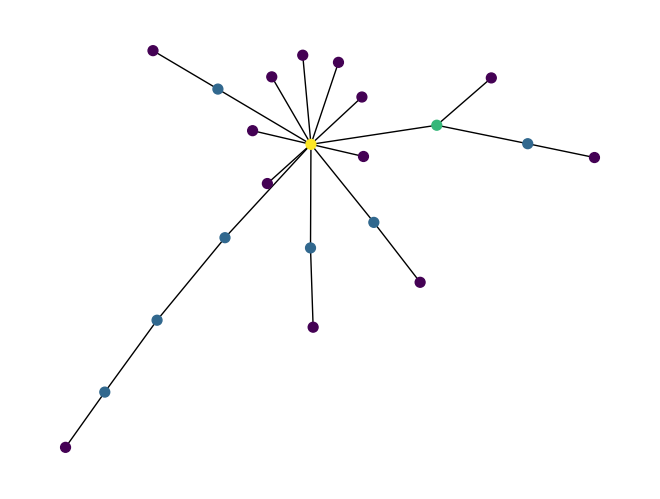

In [13]:
import networkx as nx
import numpy as np

G_ba = nx.Graph()
stubs_ba = []

#initial conditions
G_ba.add_node(0)
G_ba.add_node(1)
G_ba.add_edge(0,1)
stubs_ba.append(0)
stubs_ba.append(1)
G_ba.nodes[0]['state'] = 1
G_ba.nodes[1]['state'] = 1

for step in range(20):
  (G_ba, stubs_ba) = preferential_attachment(G_ba, stubs_ba)

from itertools import count
groups = set(nx.get_node_attributes(G_ba,'state').values())
mapping = dict(zip(sorted(groups),count()))
colors = [mapping[G_ba.nodes[n]['state']] for n in G_ba.nodes()]

nx.draw(G_ba, with_labels=False, node_size=50, pos=nx.fruchterman_reingold_layout(G_ba), node_color=colors)

In [3]:
g = G_ba
nx.degree_centrality(g)

{0: 0.23809523809523808,
 1: 0.3333333333333333,
 2: 0.19047619047619047,
 3: 0.09523809523809523,
 4: 0.047619047619047616,
 5: 0.047619047619047616,
 6: 0.047619047619047616,
 7: 0.14285714285714285,
 8: 0.047619047619047616,
 9: 0.19047619047619047,
 10: 0.047619047619047616,
 11: 0.09523809523809523,
 12: 0.047619047619047616,
 13: 0.047619047619047616,
 14: 0.047619047619047616,
 15: 0.047619047619047616,
 16: 0.047619047619047616,
 17: 0.047619047619047616,
 18: 0.047619047619047616,
 19: 0.047619047619047616,
 20: 0.047619047619047616,
 21: 0.047619047619047616}

hot potato 

deflects to neighbors minimizes cost to one node not to neighbors

In [22]:
import networkx as nx
import numpy as np
import random


def run_hot_potato():

    g = G_ba
    history = []
    hops=[]
    for node in g.nodes:
        g.nodes[node]['state'] = list()
    nextg = g.copy()

  
    for step in range(10):
        for node in g.nodes:
            #remove destined for node
            state=g.nodes[node]['state']
            next_state = [packet for packet in state if packet != node]

            random_neighbors = (list(g.neighbors(node)))
            random.shuffle(random_neighbors)
            for neighbor in random_neighbors:
                if  len(next_state) > 0:
                    dest = next_state.pop()            
                    nextg.nodes[neighbor]['state'].append(dest)

            # generate a packet 
            die = random.uniform(0, 1)
            if die<p:
                dest = np.random.choice(list(g.nodes))
                next_state.append(dest)

                
            # Update the next state for the node
            nextg.nodes[node]['state'] = next_state
            delta_flow = len(next_state) - len(state)
            history.append((step, node, g.nodes[node]['state'], delta_flow))
        g = nextg     
        nextg = g.copy()

    return history

Random adaptive routing by cost to neighbor

In [31]:
import networkx as nx
import numpy as np
import random




def run_random_adaptive_routing():

    def cost(j):
        F = len(g.nodes[j]['state'])
        C = g.nodes[j]['capacity']
        return 0. if F == 0 or C == 0 else F/C


    #deterministic rewiring
    #random rewiring
    #null rewiring

    g = G_ba
    history = []
    hops= {}
    for node in g.nodes:
        g.nodes[node]['state'] = list()
        g.nodes[node]['capacity'] = 2   #capacity is compute, if zero computeless node
    nextg = g.copy()


    for step in range(10):

        for node in g.nodes:
            # Remove packets destined for the current node
            state = g.nodes[node]['state']
            next_state = []
            this_round=[]
            for packet in state:
                o, d, packet_id = packet
                hops[packet] += 1
                if d == node:
                    # Packet reaches its destination; 
                    continue
                else:
                    next_state.append(packet)

            random_neighbors=(list(g.neighbors(node)))
            cost_distribution = np.array([cost(n) for n in (random_neighbors)])
            cost_distribution /= 1. if sum(cost_distribution) == 0. else sum(cost_distribution)
            cost_distribution = 1. - cost_distribution + 1e-6  # Add a small value to avoid zeros
            cost_distribution /= sum(cost_distribution)
        
            random_neighbors = np.random.choice(list(g.neighbors(node)), p=cost_distribution, replace=True, size=len(random_neighbors))      
            #  adaptive routing in that edge weight is reassigned to chosen neighbor
            for neighbor in random_neighbors:
                if len(next_state) > 0:
                    packet = next_state.pop()            
                    nextg.nodes[neighbor]['state'].append(packet)  
                    this_round.append((node,neighbor,packet))   # to add to memory
            # generate a packet 
            die = random.uniform(0, 1)
            if die<p:
                dest = np.random.choice(list(g.nodes))
                packet = (node, dest, step)
                next_state.append(packet)
                hops[packet] = 0

                
            # Update the next state for the node
            nextg.nodes[node]['state'] = next_state
            history.append((step, node, g.nodes[node]['state'], this_round))
            
            
        g = nextg     
        nextg = g.copy()

    return history

Shortest path noncooperative routing

In [14]:
import networkx as nx
import numpy as np
import random


def run_shortest_path_routing():
    #deterministic rewiring
    #random rewiring
    #null rewiring
 
    g = G_ba
    history = []
    hops= {}
    for node in g.nodes:
        g.nodes[node]['state'] = list()
        g.nodes[node]['capacity'] = 2   #capacity is compute, if zero computeless node
    nextg = g.copy()


    for step in range(10):
        for node in g.nodes:
            # Remove packets destined for the current node
            state = g.nodes[node]['state']
            next_state = []
            for packet in state:
                o, d, packet_id = packet
                hops[packet] += 1
                if d == node:
                    # Packet reaches its destination
                    continue
                else:
                    next_state.append(packet)

            # Process neighbors for packet forwarding
            for packet in next_state[:]:  # Use a copy to avoid modifying during iteration
                o, d, packet_id = packet
                try:
                    # Get the next hop on the shortest path to the destination
                    path = nx.shortest_path(g, source=node, target=d, weight="weight")
                    if len(path) > 1:  # If there's a valid path
                        next_hop = path[1]  # The next node in the path
                        nextg.nodes[next_hop]['state'].append(packet)  # Forward packet
                        next_state.remove(packet)  # Remove from current node
                except nx.NetworkXNoPath:
                    # No path exists; keep packet in the current node's state
                    continue

            # Generate a packet with a given probability
            die = random.uniform(0, 1)
            if die < p:
                dest = np.random.choice(list(g.nodes))
                packet = (node, dest, step)
                next_state.append(packet)
                hops[packet] = 0

            # Update the next state for the node
            nextg.nodes[node]['state'] = next_state
            delta_flow = len(next_state) - len(state)
            history.append((step, node, g.nodes[node]['state'], delta_flow))

        # Update the graph
        g = nextg
        nextg = g.copy()
    return history



plot

In [17]:
#helpers
import matplotlib.pyplot as plt

def plot_history_per_simulation(histories):
    """
    Plot the state count over time for each node, per simulation.

    Args:
        histories (list of tuples): Each tuple contains a simulation label (str) and its corresponding history.
    """
    import matplotlib.pyplot as plt

    for simulation, history in histories:
        # Prepare state history for each node
        state_history = {}
        for step, node, state, delta_flow in history:
            if node not in state_history:
                state_history[node] = []
            state_history[node].append((step, len(state)))

        # Plot state count over time for the current simulation
        plt.figure(figsize=(10, 6))
        for node, data in state_history.items():
            steps, counts = zip(*data)
            plt.plot(steps, counts, label=f"Node {node}")
        
        # Add labels, title, and legend
        plt.xlabel("Time Step")
        plt.ylabel("State Count")
        plt.title(f"State Count Over Time for Each Node ({simulation})")
        plt.legend(title="Nodes", loc="upper right", fontsize="small")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.tight_layout()
        plt.show()


def plot_avg_flow_rate_with_degree(histories):
    """
    Plot average flow rate and normalized degree distribution per node for multiple simulations to compare.
    
    Args:
        histories (list of tuples): Each tuple contains a simulation label (str) and its corresponding history.
        g (nx.Graph): The graph object to calculate degree distribution.
    """
    import matplotlib.pyplot as plt

    # Initialize a list to store flow rates and corresponding labels
    all_flow_rates = []

    for simulation, history in histories:
        # Initialize a dictionary to count the total packets processed per node
        flow_counts = {node: 0 for node in g.nodes}

        # Calculate the total flow (packets sent and received) for each node
        for step, node, state, delta_flow in history:
            flow_counts[node] += len(state)  # Add the number of packets processed at this step

        # Normalize flow counts to form a probability distribution
        total_flow = sum(flow_counts.values())
        avg_flow_rate = {node: flow_counts[node] / total_flow for node in g.nodes}
        all_flow_rates.append((simulation, avg_flow_rate))

    # Calculate and normalize degree distribution
    degrees = {node: g.degree[node] for node in g.nodes}
    total_degree = sum(degrees.values())
    normalized_degrees = {node: degree / total_degree for node, degree in degrees.items()}

    # Plot the flow rates and degree distribution
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot degree distribution with black circles
    node_labels = list(g.nodes)
    degree_values = [normalized_degrees[node] for node in node_labels]
    ax1.scatter(
        node_labels,
        degree_values,
        color="black",
        label="Normalized Degree Distribution",
        alpha=0.7
    )

    # Plot flow rates for each simulation
    for simulation, avg_flow_rate in all_flow_rates:
        flow_rates = [avg_flow_rate[node] for node in node_labels]
        ax1.scatter(
            node_labels,
            flow_rates,
            label=f"{simulation} (Normalized Flow Rate)",
            alpha=0.7
        )

    # Set labels and title
    ax1.set(
        xlabel="Node Label",
        ylabel="Normalized Value",
        title="Comparison of Normalized Flow Rate and Degree Distribution",
    )
    ax1.grid(True, linestyle="--", linewidth=0.5)
    ax1.legend(title="Metrics")

    plt.tight_layout()
    plt.show()

def plot_state_variance(histories):
    """
    Plot variance in state (packet counts) over all nodes for each simulation over time.
    
    Args:
        histories (list of tuples): Each tuple contains a simulation label (str) and its corresponding history.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Initialize a dictionary to store variances over time for each simulation
    variances_over_time = []

    for simulation, history in histories:
        # Group state counts by time step
        time_steps = sorted(set(step for step, _, _, _ in history))
        variance_per_step = []

        for step in time_steps:
            # Extract state counts for all nodes at the current step
            state_counts = [len(state) for t, node, state, flow_delta in history if t == step]

            # Calculate variance of state counts
            variance_per_step.append(np.var(state_counts))

        variances_over_time.append((simulation, time_steps, variance_per_step))

    # Plot the variance for each simulation
    plt.figure(figsize=(10, 6))

    for simulation, time_steps, variance_per_step in variances_over_time:
        plt.plot(time_steps, variance_per_step, label=simulation, marker="o", alpha=0.7)

    # Set labels and title
    plt.xlabel("Time Step")
    plt.ylabel("Variance in State (Packet Counts)")
    plt.title("Variance in Node States Over Time (Comparison Across Simulations)")
    plt.grid(True, linestyle="--", linewidth=0.5)
    plt.legend(title="Simulations")

    plt.tight_layout()
    plt.show()


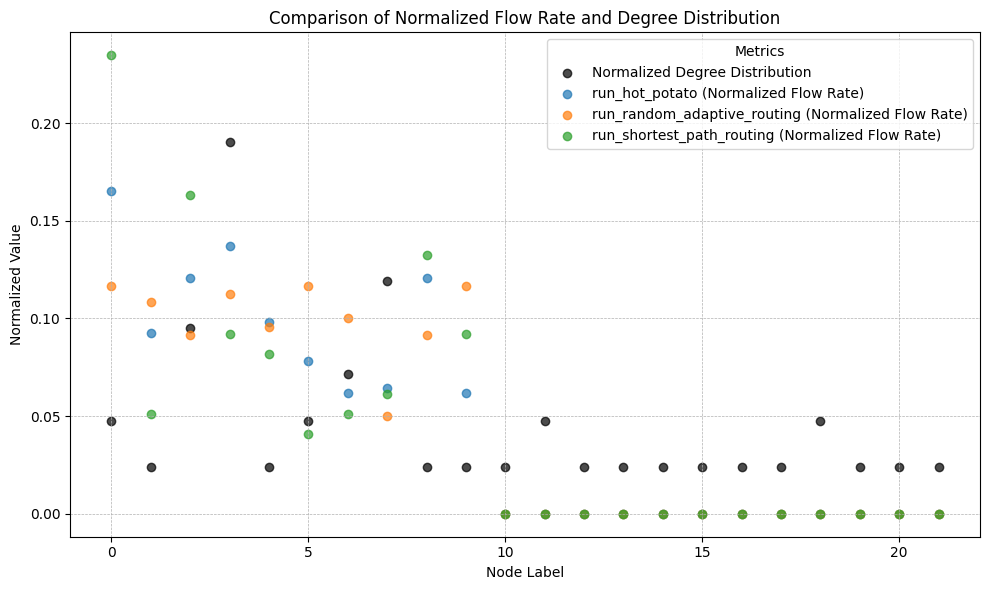

In [32]:
p = 0.5

histories = ((run_hot_potato.__name__, run_hot_potato()),
        (run_random_adaptive_routing.__name__, run_random_adaptive_routing()),
        (run_shortest_path_routing.__name__, run_shortest_path_routing())
    )
plot_avg_flow_rate_with_degree(histories)



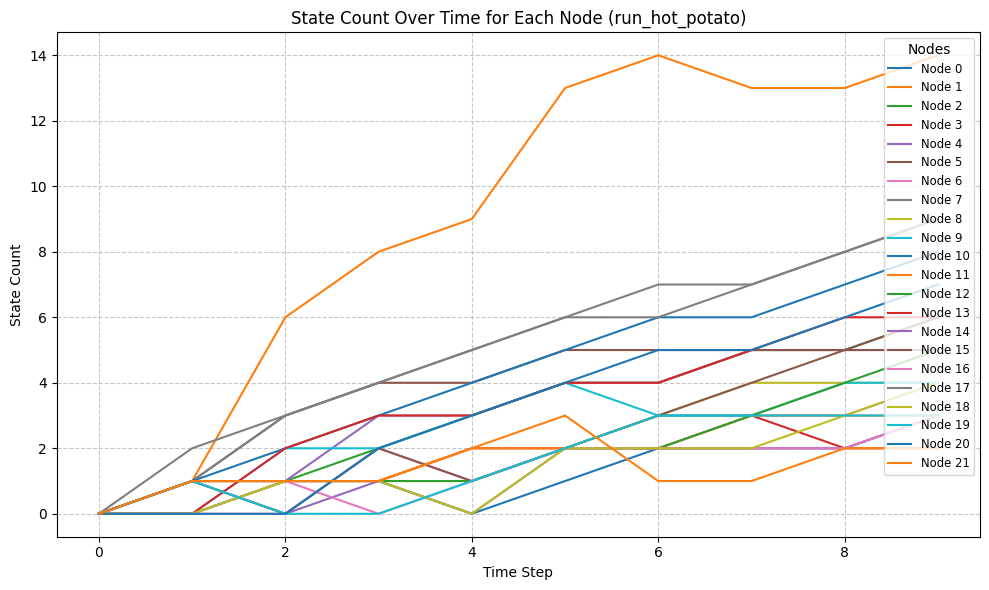

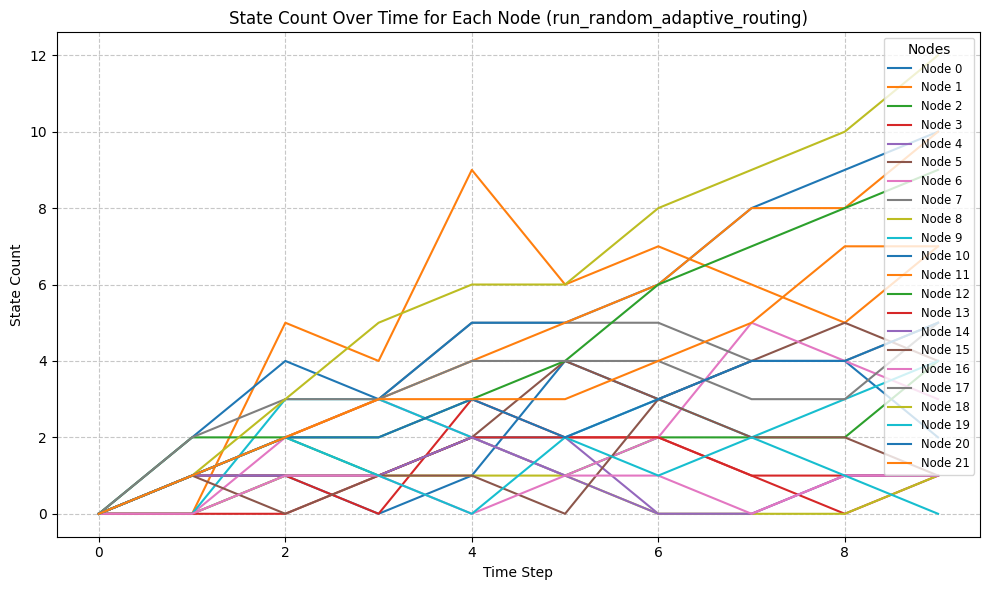

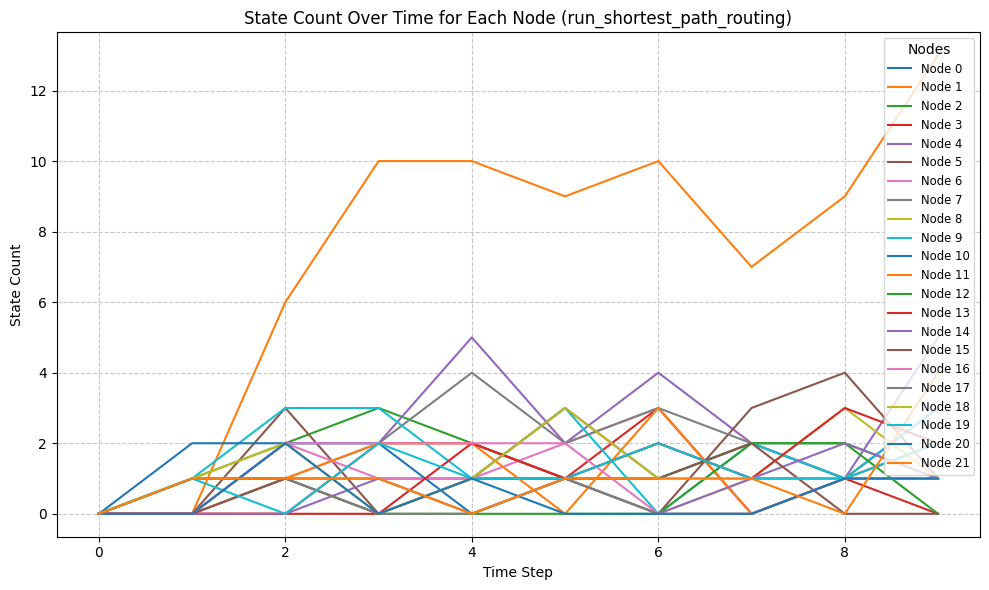

In [ ]:
plot_history_per_simulation(histories)

All moves

In [102]:
import random
import numpy as np
import networkx as nx

def run_simulation_with_node_moves(g, steps=10, p=0.5, 
                                   move_distribution=[1/3, 1/3, 1/3], 
                                   capacity=2, 
                                   payoff_matrix=[[-9, 3, 24], [2, 20, -8], [14, -8, -8]]):


    def hot_potato_move(node, next_state):
        random_neighbors = list(g.neighbors(node))
        random.shuffle(random_neighbors)
        for neighbor in random_neighbors:
            if len(next_state) > 0:
                packet = next_state.pop()
                if cost_enforced(node, neighbor, packet):
                    continue
                nextg.nodes[neighbor]['state'].append(packet)
                this_round.append((g.nodes[node]['move'], g.nodes[neighbor]['move'], packet))

    def adaptive_move(node, next_state):
        random_neighbors = list(g.neighbors(node))
        cost_distribution = np.array([cost(n) for n in random_neighbors])
        if sum(cost_distribution) > 0:
            cost_distribution = 1. - cost_distribution / sum(cost_distribution) + 1e-6
            cost_distribution /= sum(cost_distribution)
        else:
            cost_distribution = np.ones(len(random_neighbors)) / len(random_neighbors)

        chosen_neighbors = np.random.choice(random_neighbors, p=cost_distribution, size=len(next_state), replace=True)
        for neighbor in chosen_neighbors:
            if len(next_state) > 0:
                packet = next_state.pop()
                if cost_enforced(node, neighbor, packet):
                        continue
                nextg.nodes[neighbor]['state'].append(packet)
                this_round.append((g.nodes[node]['move'], g.nodes[neighbor]['move'], packet))

    def shortest_path_move(node, next_state):
        while  len(next_state) > 0:
            packet = next_state.pop()
            o, d, packet_id = packet
            try:
                path = nx.shortest_path(g, source=node, target=d, weight="weight")
                if len(path) > 1:
                    neighbor = path[1]
                    if cost_enforced(node, neighbor, packet):
                        continue
                    nextg.nodes[neighbor]['state'].append(packet)
                    this_round.append((g.nodes[node]['move'], g.nodes[neighbor]['move'], packet))
            except nx.NetworkXNoPath:
                continue

    def cost(j):
        F = len(g.nodes[j]['state'])
        C = g.nodes[j]['capacity']
        return 0. if F == 0 or C == 0 else F / C

    def cost_enforced(node, neighbor, packet) :
        if len(g.nodes[neighbor]['state']) >= g.nodes[neighbor]['capacity']: # if added packet exceeds neighbor capacity
            # cost actualized is packet rejected
            rejected.append(packet)
            return True


    history = []
    received = []
    rejected = []
    hops = {}
    moves = [hot_potato_move, adaptive_move, shortest_path_move]
    for node in g.nodes:
        g.nodes[node]['state'] = list()
        g.nodes[node]['capacity'] = capacity
        g.nodes[node]['move'] = np.random.choice(moves, p=move_distribution)
    nextg = g.copy()

    for step in range(steps):
        
        for node in g.nodes:
            state = g.nodes[node]['state']
            next_state = []
            this_round=[]

            #receive packets
            for packet in state:
                o, d, packet_id = packet
                hops[packet] += 1
                if d == node:
                    # Packet reaches its destination; 
                    received.append(packet)
                    continue
                else:
                    next_state.append(packet)


            #make next move
            neighbor_moves =[g.nodes[neighbor]['move'] for neighbor in g.neighbors(node)]
            j_player_move = np.random.choice(neighbor_moves)            
            #use payoff matrix
            payoff_matrix = np.array(payoff_matrix)
            given_j =payoff_matrix[:, moves.index(j_player_move)] 
            move = moves[ np.argmax(given_j)] #... use max but better to use probability?
            move(node, next_state)
            nextg.nodes[node]['move'] = move


            # generate 1 new packet
            if random.uniform(0, 1) < p  :
                dest = np.random.choice(list(g.nodes))
                packet = (node, dest, step)
                next_state.append(packet)
                hops[packet] = 0

            nextg.nodes[node]['state'] = next_state
            history.append((step, node, g.nodes[node]['state'], this_round))

        g = nextg
        nextg = g.copy()

    return history, hops, received, rejected, moves



history, hops, received, rejected, moves = run_simulation_with_node_moves(g)


In [103]:
def calculate_payoff_matrix(history, hops, received, rejected, moves):
    # Initialize counters for the 3x3 matrix for (Hot Potato, Adaptive, Shortest Path)
    move_labels = ['Hot Potato', 'Adaptive', 'Shortest Path']
    move_pairs = {('Hot Potato', 'Hot Potato'): [0, 0],
                  ('Hot Potato', 'Adaptive'): [0, 0],
                  ('Hot Potato', 'Shortest Path'): [0, 0],
                  ('Adaptive', 'Hot Potato'): [0, 0],
                  ('Adaptive', 'Adaptive'): [0, 0],
                  ('Adaptive', 'Shortest Path'): [0, 0],
                  ('Shortest Path', 'Hot Potato'): [0, 0],
                  ('Shortest Path', 'Adaptive'): [0, 0],
                  ('Shortest Path', 'Shortest Path'): [0, 0]}

    # Count the number of received and rejected packets for each pair of moves
    for step, node, state, this_round in history:
        for move_pair in this_round:
            sender_move, receiver_move, packet = move_pair
            sender_label = move_labels[moves.index(sender_move)]
            receiver_label = move_labels[moves.index(receiver_move)]
            move_pairs[(sender_label, receiver_label)][0] += 1  # Received count

    for packet in rejected:
        o, d, packet_id = packet
        move_pair = (g.nodes[o]['move'], g.nodes[d]['move'])
        sender_label = move_labels[moves.index(move_pair[0])]
        receiver_label = move_labels[moves.index(move_pair[1])]
        move_pairs[(sender_label, receiver_label)][1] += 1  # Rejected count

    # Prepare the payoff matrix for received - rejected
    payoff_data = []
    for sender in move_labels:
        row = []
        for receiver in move_labels:
            received, rejected = move_pairs[(sender, receiver)]
            payoff = (received - rejected)
            row.append(received - rejected)
        payoff_data.append(row)

    # Display the payoff matrix using pandas
    payoff_matrix = pd.DataFrame(payoff_data, index=move_labels, columns=move_labels)

    return payoff_matrix


# Example Usage
G_ba = nx.barabasi_albert_graph(100, 2)
history, hops, received, rejected, moves = run_simulation_with_node_moves(g, steps=10, p=0.5, move_distribution=[1/3, 1/3, 1/3], capacity=2)
payoff_matrix = calculate_payoff_matrix(history, hops, received, rejected, moves)
print("Payoff Matrix (Received - Rejected):")
print(payoff_matrix)

history, hops, received, rejected, moves = run_simulation_with_node_moves(g, steps=10, p=0.5, move_distribution=[2/3, 1/3, 0], capacity=2)
payoff_matrix = calculate_payoff_matrix(history, hops, received, rejected, moves)

Payoff Matrix (Received - Rejected):
               Hot Potato  Adaptive  Shortest Path
Hot Potato             30         8             -4
Adaptive               -1        -7            -13
Shortest Path          -5         3             24


In [ ]:
import itertools
import numpy as np

# Function to generate all valid move distributions
def generate_move_distributions(fractions):
    distributions = []
    for combo in itertools.product(fractions, repeat=3):
        if sum(combo) == 1:  # Ensure the distribution sums to 1
            distributions.append(combo)
    return distributions

results=[]
for combo in generate_move_distributions([0, 1/3, 2/3, 1]):
    history, hops, received, rejected, moves = run_simulation_with_node_moves(g, steps=10, p=0.5, move_distribution=combo, capacity=2)
    payoff_matrix = calculate_payoff_matrix(history, hops, received, rejected, moves)
    results.append(payoff_matrix)
    print(combo)
    print("Payoff Matrix (Received - Rejected):")
    print(payoff_matrix)



(0, 0, 1)
Payoff Matrix (Received - Rejected):
               Hot Potato  Adaptive  Shortest Path
Hot Potato              0         0              0
Adaptive                0         0              0
Shortest Path           0         0             11
(0, 0.3333333333333333, 0.6666666666666666)
Payoff Matrix (Received - Rejected):
               Hot Potato  Adaptive  Shortest Path
Hot Potato              0         0              0
Adaptive                0         1             -2
Shortest Path           0         0             21
(0, 0.6666666666666666, 0.3333333333333333)
Payoff Matrix (Received - Rejected):
               Hot Potato  Adaptive  Shortest Path
Hot Potato              0         0              0
Adaptive                0        14              7
Shortest Path           0         1              5
(0, 1, 0)
Payoff Matrix (Received - Rejected):
               Hot Potato  Adaptive  Shortest Path
Hot Potato              0         0              0
Adaptive                0     

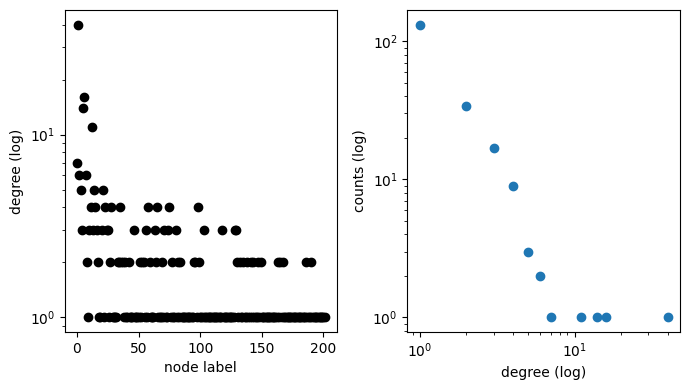

In [ ]:
import matplotlib.pyplot as plt

degree_freq = nx.degree_histogram(G_ba)
degrees = range(len(degree_freq))

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7, 4), tight_layout=True)
ax1.plot(G_ba.nodes, nx.get_node_attributes(G_ba,'state').values(), 'ko')
ax1.set(xlabel='node label', ylabel='degree (log)')
ax1.set(yscale='log')
ax2.loglog(degrees[1:], degree_freq[1:],'o')
ax2.set(xlabel='degree (log)', ylabel='counts (log)')
plt.show()

# Erdős-Rényi model

Fully random network where every pair of nodes is connected with probability p

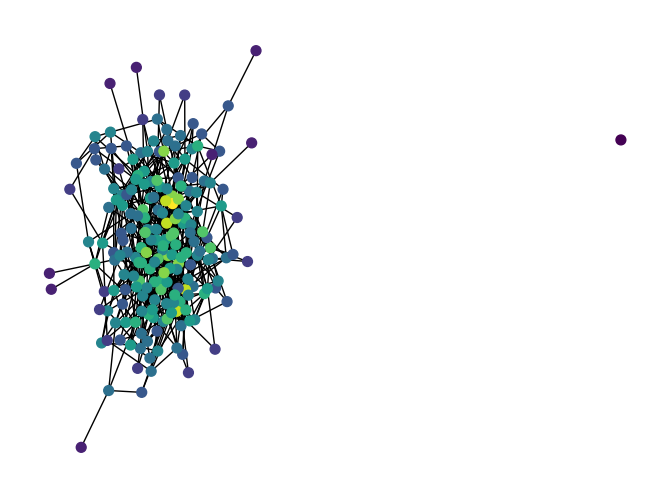

In [ ]:
#@title Random network generation { run: "auto" }

import networkx as nx
import numpy as np
import random

G_er = nx.Graph()

#density parameter
p = 0.027 #@param {type:"slider", min:0, max:1, step:0.001}

for node in range(200):
  G_er.add_node(node)
  G_er.nodes[node]['state'] = 0
  for neighbor in range(G_er.number_of_nodes()-1):
    die = random.uniform(0, 1)
    if die<p: #create an edge
       G_er.add_edge(node,neighbor)
       G_er.nodes[node]['state'] += 1
       G_er.nodes[neighbor]['state'] += 1

from itertools import count
groups = set(nx.get_node_attributes(G_er,'state').values())
mapping = dict(zip(sorted(groups),count()))
colors = [mapping[G_er.nodes[n]['state']] for n in G_er.nodes()]

nx.draw(G_er, with_labels=False, node_size=50, pos=nx.fruchterman_reingold_layout(G_er), node_color=colors)

In [ ]:
n = 200
print('p_perc =', 1/n, '("giant connected component" critical point || percolation threshold)')
print('p_conn =', np.log(n)/n, '("connectedness" critical point)')

p_perc = 0.005 ("giant connected component" critical point || percolation threshold)
p_conn = 0.02649158683274018 ("connectedness" critical point)


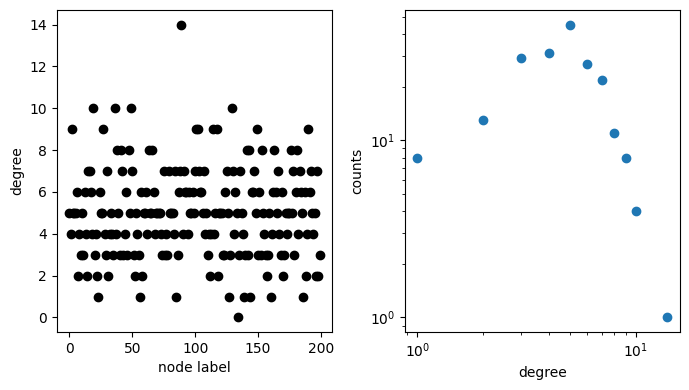

In [ ]:
import matplotlib.pyplot as plt

degree_freq = nx.degree_histogram(G_er)
degrees = range(len(degree_freq))

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7, 4), tight_layout=True)
ax1.plot(G_er.nodes, nx.get_node_attributes(G_er,'state').values(), 'ko')
ax1.set(xlabel='node label', ylabel='degree')
ax2.loglog(degrees[1:], degree_freq[1:],'o')
ax2.set(xlabel='degree', ylabel='counts')
plt.show()

# Configuration model

Degree-preserving, random connection of a degree sequence

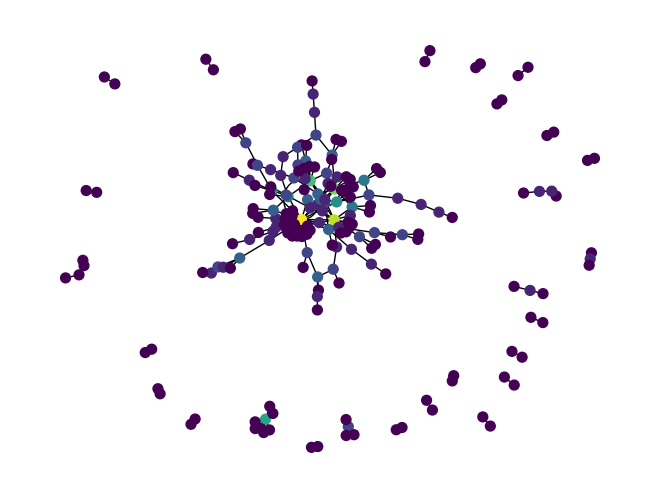

In [ ]:
#Degree-preserving randomization
import networkx as nx
import numpy as np
import random

#Run a preferential attachment model (for example)
# G = nx.Graph()
# stubs = []

# #initial conditions
# G.add_node(0)
# G.add_node(1)
# G.add_edge(0,1)
# stubs.append(0)
# stubs.append(1)
# G.nodes[0]['state'] = 1
# G.nodes[1]['state'] = 1

# for step in range(100):
#   (G, stubs) = preferential_attachment(G, stubs)

#delete the network but keep degrees
G_cm = nx.create_empty_copy(G_ba)

#rewire the network
#shuffle degrees
stubs = stubs_ba
np.random.shuffle(stubs)
firststubs = stubs[0::2] # select elements in even entries
secondstubs = stubs[1::2] # select elements in odd entries
#connect degrees by pairs
for e in range(len(firststubs)):
  G_cm.add_edge(firststubs[e],secondstubs[e])

from itertools import count
groups = set(nx.get_node_attributes(G_cm,'state').values())
mapping = dict(zip(sorted(groups),count()))
colors = [mapping[G_cm.nodes[n]['state']] for n in G_cm.nodes()]

nx.draw(G_cm, with_labels=False, node_size=50, pos=nx.fruchterman_reingold_layout(G_cm), node_color=colors)

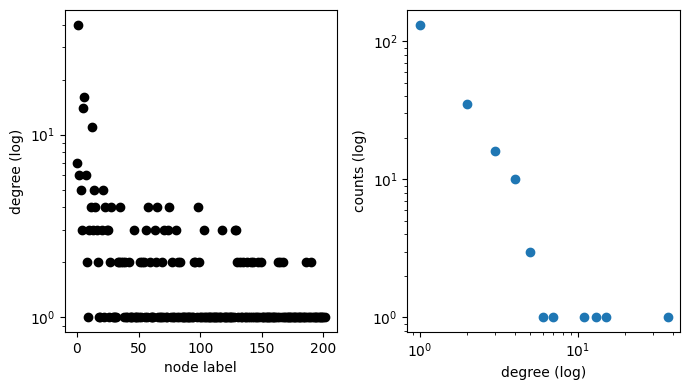

In [ ]:
import matplotlib.pyplot as plt

degree_freq = nx.degree_histogram(G_cm)
degrees = range(len(degree_freq))

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7, 4), tight_layout=True)
ax1.plot(G_cm.nodes, nx.get_node_attributes(G_cm,'state').values(), 'ko')
ax1.set(xlabel='node label', ylabel='degree (log)')
ax1.set(yscale='log')
ax2.loglog(degrees[1:], degree_freq[1:],'o')
ax2.set(xlabel='degree (log)', ylabel='counts (log)')
plt.show()

# Uniform attachment

Uniform, unbiased attachment

In [ ]:
#import networkx as nx
import numpy as np

def uniform_attachment(G):
  #pick attachment
  neighbor = np.random.choice(G.nodes)
  #add new node
  new_node = G.number_of_nodes()
  G.add_node(new_node)
  #pick attachment
  #add edge
  G.add_edge(new_node, neighbor)
  #update degrees
  G.nodes[new_node]['state'] = 1
  G.nodes[neighbor]['state'] += 1
  return(G)

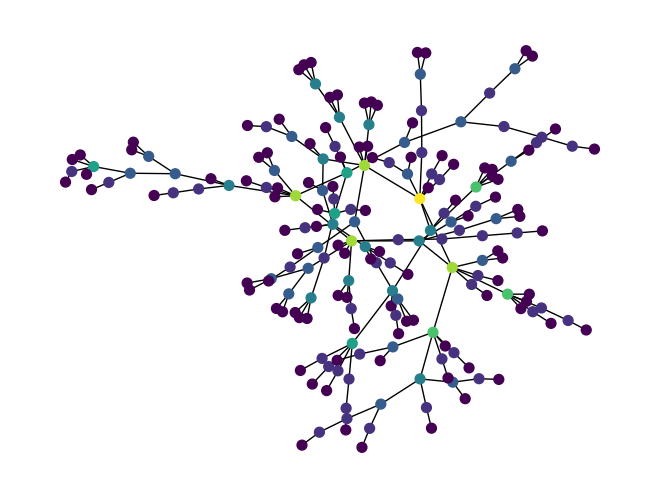

In [ ]:
import networkx as nx
import numpy as np

G_un = nx.Graph()

#initial conditions
G_un.add_node(0)
G_un.add_node(1)
G_un.add_edge(0,1)
G_un.nodes[0]['state'] = 1
G_un.nodes[1]['state'] = 1

for step in range(200):
  G_un = uniform_attachment(G_un)

from itertools import count
groups = set(nx.get_node_attributes(G_un,'state').values())
mapping = dict(zip(sorted(groups),count()))
colors = [mapping[G_un.nodes[n]['state']] for n in G_un.nodes()]

nx.draw(G_un, with_labels=False, node_size=50, pos=nx.spring_layout(G_un), node_color=colors)

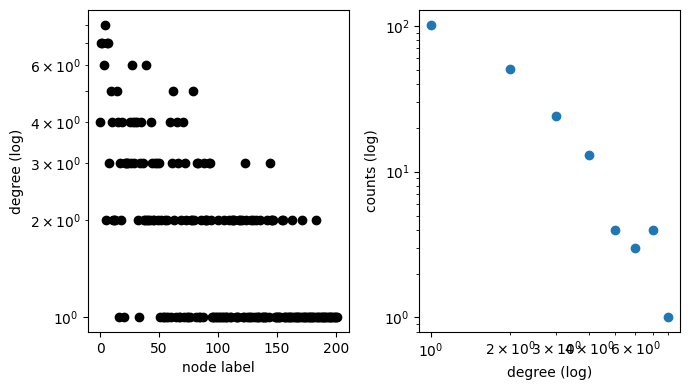

In [ ]:
import matplotlib.pyplot as plt

degree_freq = nx.degree_histogram(G_un)
degrees = range(len(degree_freq))

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7, 4), tight_layout=True)
ax1.plot(G_un.nodes, nx.get_node_attributes(G_un,'state').values(), 'ko')
ax1.set(xlabel='node label', ylabel='degree (log)')
ax1.set(yscale='log')
ax2.loglog(degrees[1:], degree_freq[1:],'o')
ax2.set(xlabel='degree (log)', ylabel='counts (log)')
plt.show()

# Generalized preferential attachment

Generalized preferential attachment with tunable bias mu

In [ ]:
import networkx as nx
import numpy as np
import random

def gen_preferential_attachment(G, chances, nu):
  #pick attachment
  neighbor = np.random.choice(G.nodes, 1, p = [x / sum(chances) for x in chances])[0]
  #add new node
  new_node = G.number_of_nodes()
  G.add_node(new_node)
  #add edge
  G.add_edge(new_node, neighbor)
  #update degrees
  chances.append(1)
  chances[neighbor] = (G.degree(neighbor))**nu
  G.nodes[new_node]['state'] = 1
  G.nodes[neighbor]['state'] += 1
  return(G, chances)

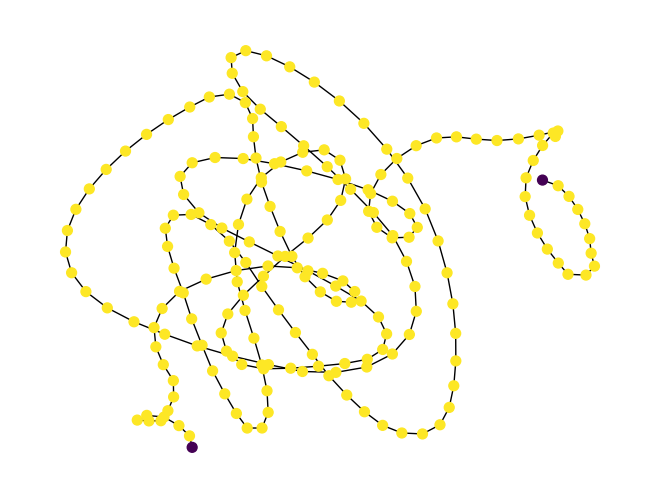

In [ ]:
#@title Generalized preferential attachment { run: "auto" }
import networkx as nx
import numpy as np

G_pa = nx.Graph()
chances = []

#attachment kernel
nu = -20  #@param {type:"slider", min:-10, max:10, step:0.05}

#initial conditions
G_pa.add_node(0)
G_pa.add_node(1)
G_pa.add_edge(0,1)
chances.append(1)
chances.append(1)
G_pa.nodes[0]['state'] = 1
G_pa.nodes[1]['state'] = 1

for step in range(200):
  (G_pa, chances) = gen_preferential_attachment(G_pa, chances, nu)

from itertools import count
groups = set(nx.get_node_attributes(G_pa,'state').values())
mapping = dict(zip(sorted(groups),count()))
colors = [mapping[G_pa.nodes[n]['state']] for n in G_pa.nodes()]

nx.draw(G_pa, with_labels=False, node_size=50, pos=nx.fruchterman_reingold_layout(G_pa), node_color=colors)

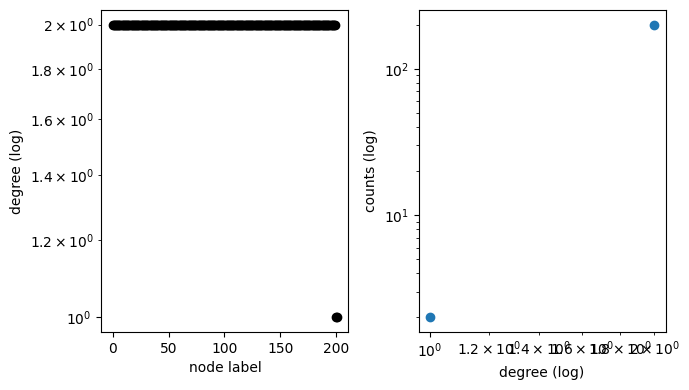

In [ ]:
import matplotlib.pyplot as plt

degree_freq = nx.degree_histogram(G_pa)
degrees = range(len(degree_freq))

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7, 4), tight_layout=True)
ax1.plot(G_pa.nodes, nx.get_node_attributes(G_pa,'state').values(), 'ko')
ax1.set(xlabel='node label', ylabel='degree (log)')
ax1.set(yscale='log')
ax2.loglog(degrees[1:], degree_freq[1:],'o')
ax2.set(xlabel='degree (log)', ylabel='counts (log)')
plt.show()